## Multi-agent tools mixedup methods

In [10]:
from langchain_community.tools import DuckDuckGoSearchRun
search1=DuckDuckGoSearchRun()

In [11]:
from langchain_experimental.tools import PythonREPLTool

python_tool=PythonREPLTool()

In [12]:
from langchain_community.tools import YahooFinanceNewsTool

finance = YahooFinanceNewsTool()
# finance.run("PNC")


In [13]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [14]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=250)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

In [15]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=250)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

In [16]:
tools=[search1,
       python_tool,
       finance,
       wiki,
       arxiv]

In [17]:
from langsmith import Client

client = Client()
prompt = client.pull_prompt("hwchase17/openai-functions-agent")

In [18]:
prompt.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='chat_history', optional=True),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='agent_scratchpad')]

In [19]:
import os
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


model=ChatGroq(model="openai/gpt-oss-120b")

In [20]:
from langchain.agents import create_agent
agent = create_agent(
    model=model,
    tools=tools,
    system_prompt="You are a helpful AI assistant that uses tools when needed."
)

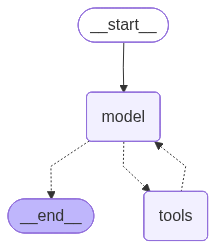

In [21]:
agent

In [22]:
agent.invoke({
    "messages": [{"role": "user", "content": "What is Agent Server?"}]
})

{'messages': [HumanMessage(content='What is Agent Server?', additional_kwargs={}, response_metadata={}, id='485826a6-311c-4134-a152-d5e2ef078e11'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is Agent Server?" Likely ambiguous term. Could refer to IBM Agent Server? Or "Agent Server" in context of AI agents, like "Agent Server" in OpenAI\'s Agent framework? Could be a generic term: a server that hosts software agents. Might need to search. Use duckduckgo.', 'tool_calls': [{'id': 'fc_87787c30-44a9-47bf-925c-6abaec1c53fb', 'function': {'arguments': '{"query":"\\"Agent Server\\" definition"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 102, 'prompt_tokens': 413, 'total_tokens': 515, 'completion_time': 0.225151642, 'completion_tokens_details': {'reasoning_tokens': 69}, 'prompt_time': 0.020055461, 'prompt_tokens_details': None, 'queue_time': 0.050916368, 'total_time': 0.245207103}, 'mo